<a href="https://colab.research.google.com/github/Elena-Kazakova-analyst/Bank-clients-credit-discipline-analysis/blob/main/bank_clients_credit_discipline_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Аналитическая задача** — провести анализ данных с целью выделения портретов заемщиков по каждой группе целевого признака.

**Примерный план исследования**

Шаг 1. Загрузка данных;

Шаг 2. Первичная обработка данных (при необходимости):
- скорректировать заголовки;
- скорректировать типы признаков;
- проверить наличие дублирующихся записей;
- проверить наличие аномальных значений;
- восстановить пропущенные значения;

Шаг 3. Добавление новых признаков:
- для каждого клиента рассчитайте его возраст на настоящий момент времени (на 2024 год);

Шаг 4. Исследовательский анализ данных
- в разрезе значений целевого признака (`Дисциплина клиентов без просрочки по кредиту`) исследовать распределения числовых и категориальных признаков;
- в разрезе значений целевого признака составить портреты клиентов платежной системы.

## Подключение библиотек

In [ ]:
import pandas as pd
import numpy as np

import datetime as dt

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Для расчета границ аномальных значений воспользуемся
# заранее подготовленной функцией

# 2 линии нижнего и верхнего усов
#для подсчета значений нижнего и верхнего усов была предложена следующая функция
def calc_boxplot(df_col : pd.Series) -> tuple:

    """
    Функция для расчета значений нижнего и верхнего усов.
    На вход подается столбец датафрейма,
    на выходе кортеж: первый элемент -- нижний ус, второй элемент -- верхний ус
    """

    Q1, median, Q3 = np.percentile(np.asarray(df_col.dropna()), [25, 50, 75])
    IQR = Q3 - Q1
    loval = Q1 - 1.5 * IQR
    hival = Q3 + 1.5 * IQR
    wiskhi = np.compress(np.asarray(df_col.dropna()) <= hival, np.asarray(df_col.dropna()))
    wisklo = np.compress(np.asarray(df_col.dropna()) >= loval, np.asarray(df_col.dropna()))
    actual_hival = np.max(wiskhi)
    actual_loval = np.min(wisklo)
    return actual_loval, actual_hival #(нижний ус, верхний ус)

## Загрузка данных и просмотр информации

In [ ]:
df = pd.read_csv('/content/dataset_segment_bank.csv')

In [ ]:
# просмотр фрагмента загруженных данных
df.head(2)

,Идентификатор,Дата рождения,Дисциплина клиентов без просрочки по кредиту,Количество переводов,Тип переводов,География переводов,География телефона,Сумма перевода,Максимальная сумма перевода,Средняя сумма перевода,Полная сумма перевода,"Канал, через который пришел клиент",Оператор связи,Пол
0,1493553,1981-05-08,BAD,17.0,2.0,77.0,77.0,371600.0,265000.0,21858.8235,371600.0,Стойка,NaN,Ж
1,8130758,1979-03-06,BAD,4.0,2.0,77.0,77.0,137574.0,135000.0,34393.5000,137574.0,Стойка,NaN,М


In [ ]:
# просмотр информации о типах данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50224 entries, 0 to 50223
Data columns (total 14 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Идентификатор                                 50224 non-null  int64  
 1   Дата рождения                                 50224 non-null  object 
 2   Дисциплина клиентов без просрочки по кредиту  50223 non-null  object 
 3   Количество переводов                          50158 non-null  float64
 4   Тип переводов                                 50191 non-null  float64
 5   География переводов                           50191 non-null  float64
 6   География телефона                            48324 non-null  float64
 7   Сумма перевода                                50158 non-null  float64
 8   Максимальная сумма перевода                   50158 non-null  float64
 9   Средняя сумма перевода                        50158 non-null 

In [ ]:
# просмотр описательных статистик -- describe
(
    df.drop(columns=['Идентификатор', 'География переводов',
                     'География телефона'])
      .describe()
)


,Количество переводов,Тип переводов,Сумма перевода,Максимальная сумма перевода,Средняя сумма перевода,Полная сумма перевода
count,50158.000000,50191.000000,5.015800e+04,5.015800e+04,50158.000000,5.015800e+04
mean,17.290821,13.186328,2.995784e+05,1.676934e+05,34478.895504,2.995784e+05
std,34.801316,22.298265,4.527366e+05,1.410307e+05,43548.644155,4.527366e+05
min,1.000000,-1.000000,3.000000e+01,3.000000e+01,30.000000,3.000000e+01
25%,4.000000,2.000000,9.225300e+04,5.500000e+04,10108.333300,9.225300e+04
50%,9.000000,5.000000,1.877303e+05,1.200000e+05,19831.931800,1.877303e+05
75%,18.000000,6.000000,3.831000e+05,2.350000e+05,41650.750000,3.831000e+05
max,2220.000000,69.000000,1.953691e+07,2.150000e+06,644225.000000,1.953691e+07


In [ ]:
# просмотр уникальных значений категориальных признаков -- поиск возможных ошибок в значениях
lst_cat_vars = ['Дисциплина клиентов без просрочки по кредиту',
                'Тип переводов', 'География переводов',
                'География телефона', 'Канал, через который пришел клиент',
                'Оператор связи', 'Пол']

for col in lst_cat_vars:
    print(f"------ {col} ----------")
    print(df[col].unique())
    print()
    print(f"------ END ----------")



------ Дисциплина клиентов без просрочки по кредиту ----------
['BAD' 'GOOD' 'MIDDLE' nan]

------ END ----------
------ Тип переводов ----------
[ 2. 69.  1.  5.  8. 32.  0. 10. 26. 12.  6. 45. 11. 33. 16.  7. 37. 21.
 58. 19. 59. 44. 53. 28. 34.  3. 43. 29. 67. 17. 30. -1. 23. 55.  4. 61.
  9. 54. nan 49.]

------ END ----------
------ География переводов ----------
[7.70000e+01 7.10000e+01 7.40000e+01 3.40000e+01 5.90000e+01 2.30000e+01
 4.20000e+01 3.90000e+01 6.30000e+01 1.60000e+01 3.60000e+01 6.10000e+01
 2.00000e+00 7.00000e+00 4.80000e+01 6.40000e+01 8.90000e+01 5.60000e+01
 6.20000e+01 6.60000e+01 7.30000e+01 4.30000e+01 3.30000e+01 0.00000e+00
 5.40000e+01 3.50000e+01 1.30000e+01 1.80000e+01 5.20000e+01 7.60000e+01
 5.50000e+01 6.90000e+01 7.80000e+01 2.60000e+01 3.00000e+01 6.80000e+01
 4.40000e+01 6.70000e+01 3.10000e+01 2.10000e+01 5.80000e+01 7.20000e+01
 4.70000e+01 5.30000e+01 4.00000e+01 4.98002e+05 1.00000e+01 5.10000e+01
 3.70000e+01 2.40000e+01 1.20000e+01 5.70000e

In [ ]:
## промежуточные выводы по этапу:
# - данные загружены корректно;
# - для удобства дальнейшей работы следует скорректировать заголовки признаков;
# - для признака `Дата рождения` исправить тип данных на `datetime64`;
# - по некоторым признакам имеются пропуски;
# - имеются дублирующийся и производный `Средняя сумма перевода` столбцы;
# - у признака `Тип переводов` имеется странное значение "-1" -- исследовать отдельно;
# - у признака `Оператор связи` имеются ошибки в значениях -- исправить;
# - по отдельным количественным признакам, возможно, имеются аномальные значениям

## Предварительная обработка данных

In [ ]:
# На данном этапе необходимо выполнить следующие работы
#     - корректировка заголовков (если необходимо);
#     - корректировка типов данных (если необходимо);
#     - обработка дублирующихся записей;
#     - поиск и обработка аномальных записей;
#     - поиск и обработка пропущенных записей;

#Дополнительно следует выполнить работы по итогам предыдущего этапа

In [ ]:
# удаление одинаковых и производных столбцов

# определим список удаляемых столбцов
lst_col_delete = ['Средняя сумма перевода',
                  'Полная сумма перевода']
# удалим столбцы
df.drop(columns=lst_col_delete,
        inplace=True)

In [ ]:
# скорректируем значения признака `Оператор связи`

dct_replace = {'Оператор связи': {'МобильныеТелеСистемы': 'Мобильные ТелеСистемы',
                                   'Ниж-ская сот.связь': 'Нижегородская сотовая связь'}}

df.replace(dct_replace,
           inplace=True)

In [ ]:
# корректировка заголовков
df.columns = ['Идентификатор', 'Дата рождения',
              'Дисциплина клиентов', 'Количество переводов',
              'Тип переводов', 'География переводов',
              'География телефона', 'Сумма перевода',
              'Максимальная сумма перевода', 'Канал клиента',
              'Оператор связи', 'Пол']
# приведение заголовков к нижнему регистру
df.columns = df.columns.str.lower()

# замена в заголовках символа "пробел" на _
lst_columns_new = []
for col in df.columns:
    lst_columns_new.append('_'.join(col.split()))

In [ ]:
# корректировка типов данных
# pd.to_numeric -- для приведения признаков к числовым типах (int, float)
# pd.to_datetime -- для приведения признаков к дате и времени

df = df.astype({'дата рождения': 'datetime64[s]',
                'количество переводов': 'float64'},
               errors='ignore')

In [ ]:
# поиск дублей
df.duplicated().sum()

# если дубли имеются имеются, то они удаляются
df.drop_duplicates(keep='last',
                   inplace=True)

In [ ]:
df.columns

Index(['идентификатор', 'дата рождения', 'дисциплина клиентов',
       'количество переводов', 'тип переводов', 'география переводов',
       'география телефона', 'сумма перевода', 'максимальная сумма перевода',
       'канал клиента', 'оператор связи', 'пол'],
      dtype='object')

In [ ]:
# поиск и обработка аномальных записей
# категориальные признаки

lst_vars_cat = ['дисциплина клиентов', 'тип переводов',
                'география переводов', 'канал клиента',
                'оператор связи', 'пол']

# непрерывные признаки
lst_vars_cont = ['количество переводов', 'сумма перевода',
                 'максимальная сумма перевода']

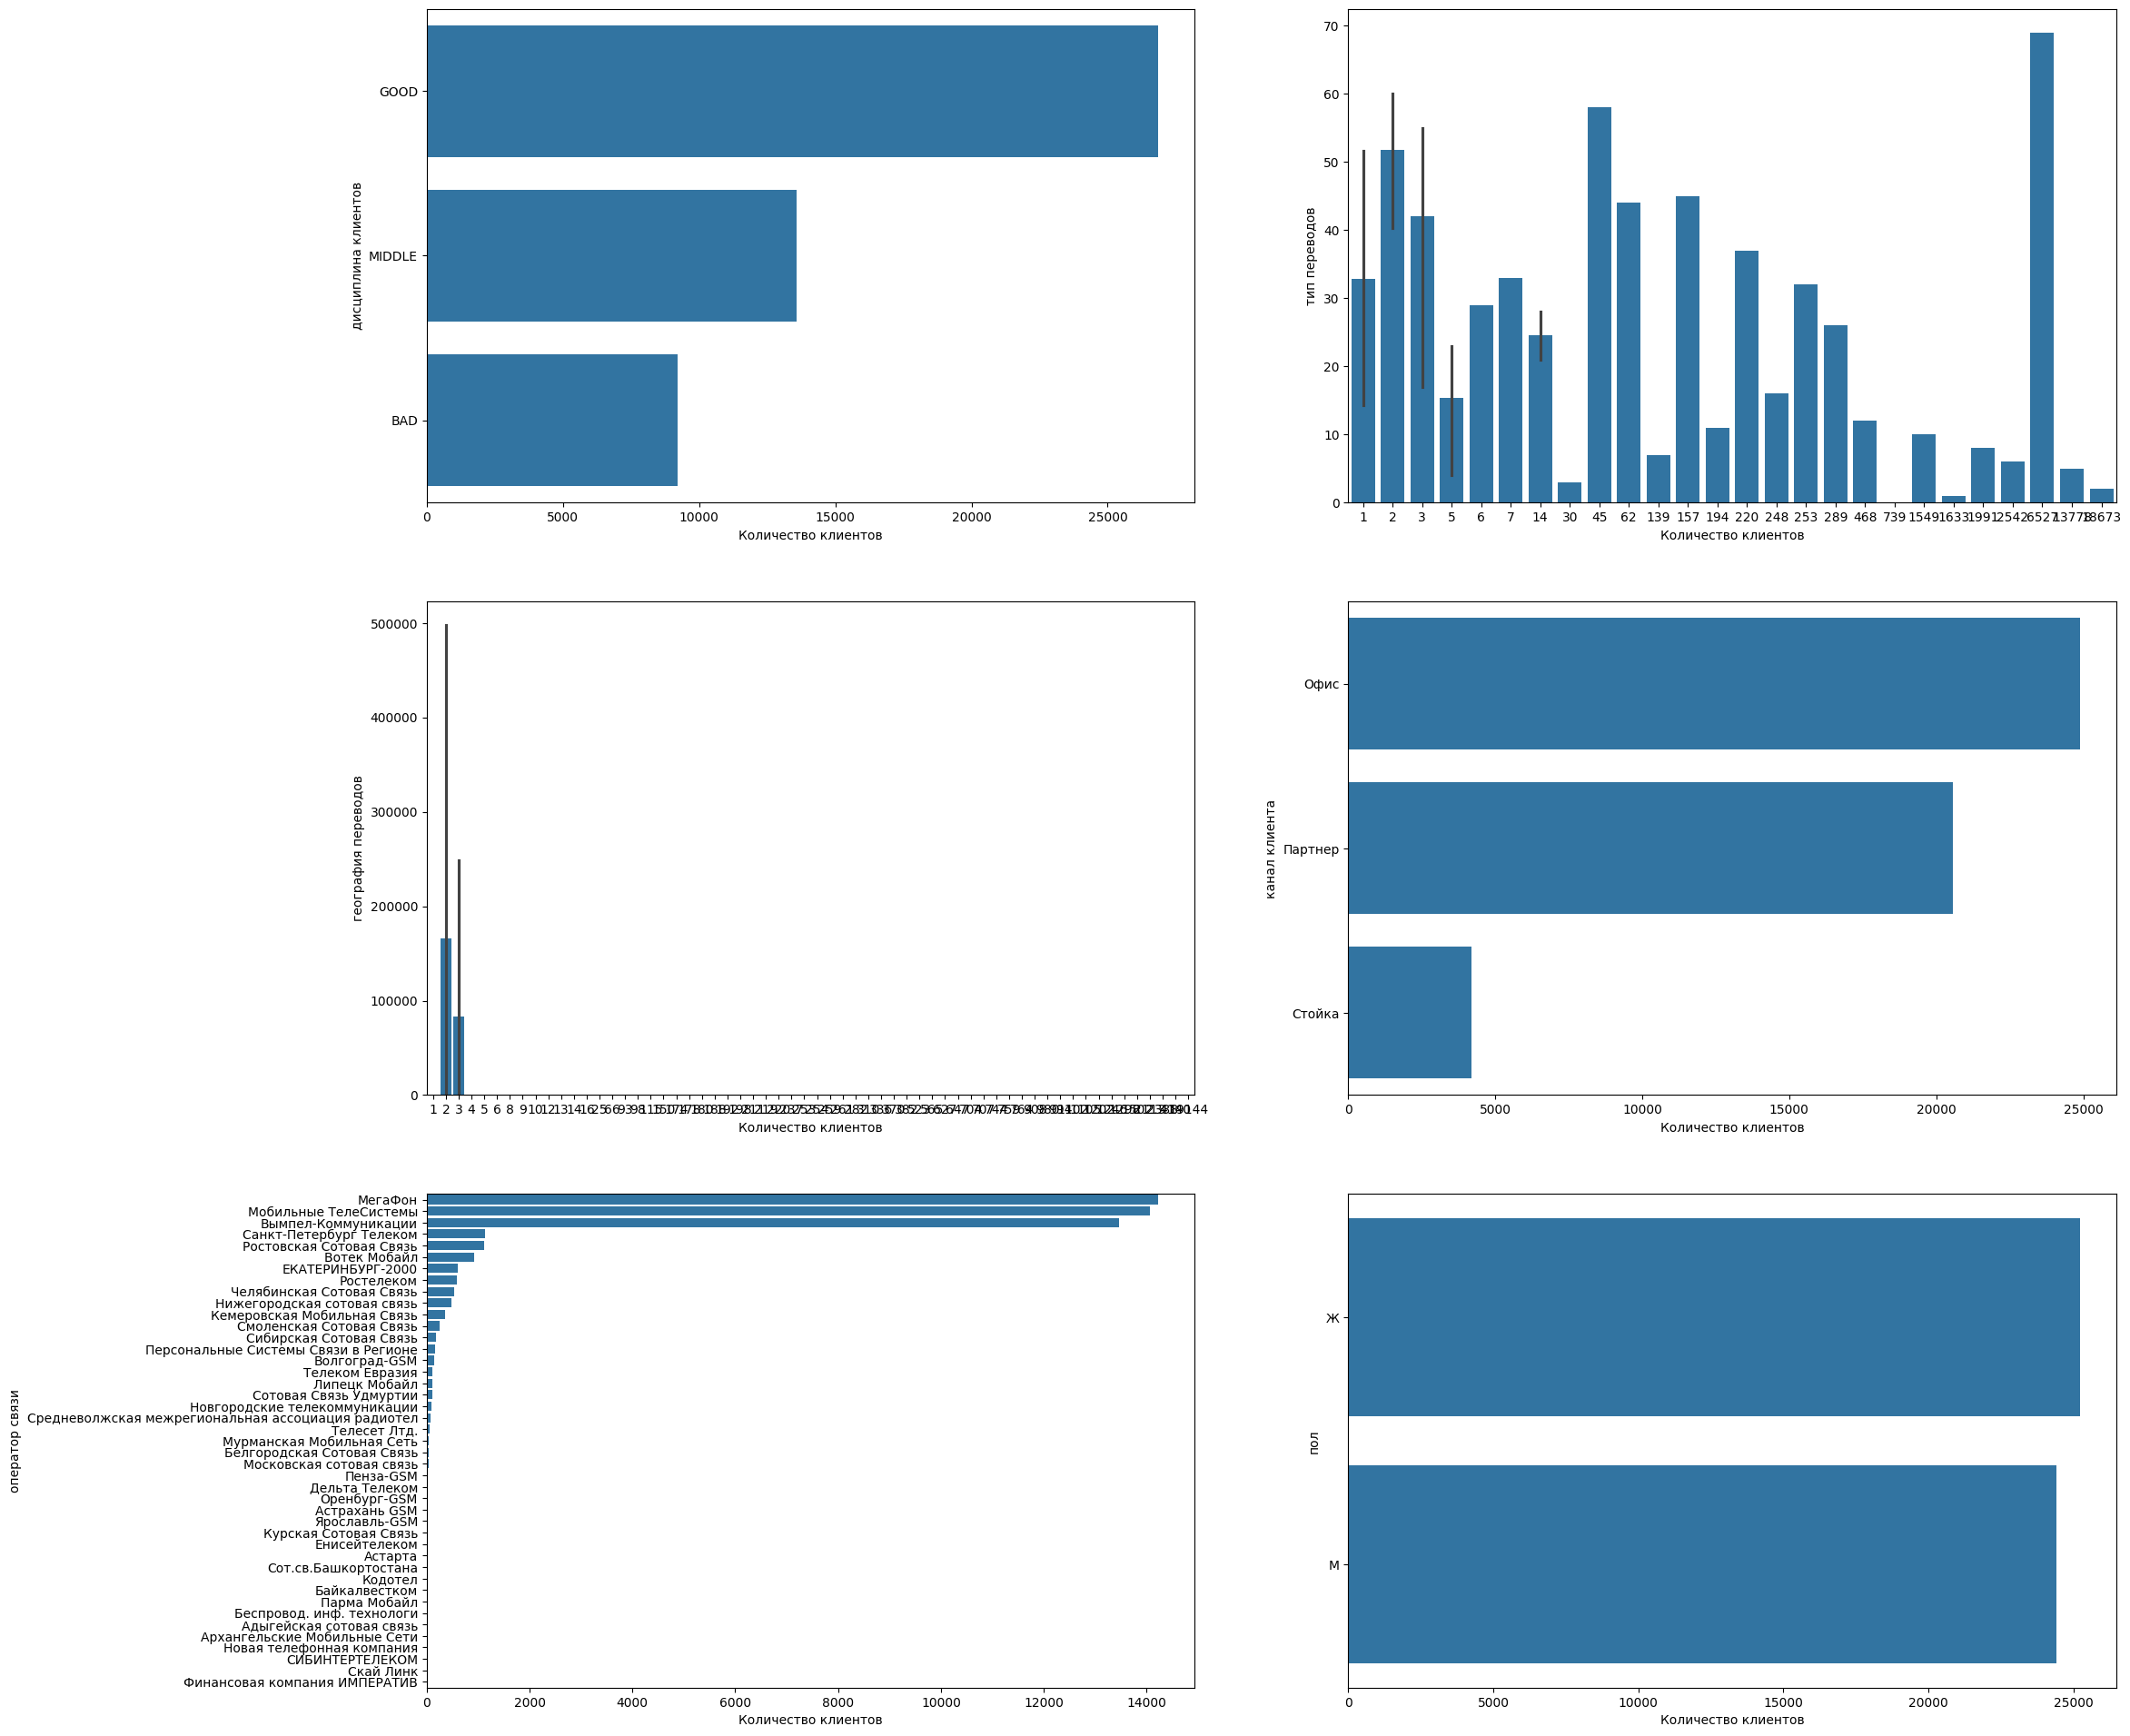

In [ ]:
# выполним визуализацию всех категориальных признаков

lst_vars_cat = ['дисциплина клиентов', 'тип переводов',
                'география переводов', 'канал клиента',
                'оператор связи', 'пол']

# зададим сетку для отображения графиков
plt.subplots(3,2, figsize=(24,24))

for index, col in enumerate(lst_vars_cat, start=1):
    df_viz = (
        df.groupby(col)
          .agg(count_value = ('идентификатор', 'count'))
          .sort_values(by='count_value', ascending=False)
          .reset_index()
          )

    plt.subplot(3,2, index)
    ax = sns.barplot(y=df_viz[col],
                 x=df_viz['count_value'])
    ax.set_xlabel('Количество клиентов')
    ax.set_ylabel(col)

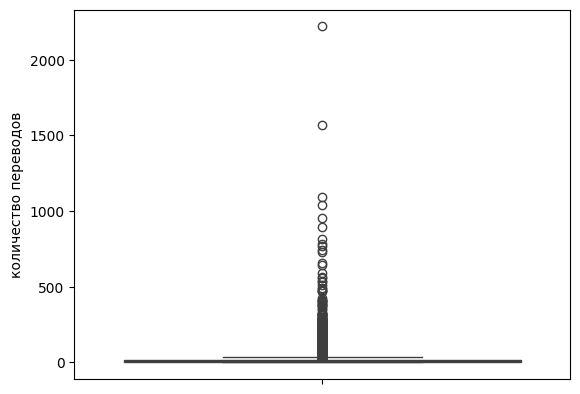

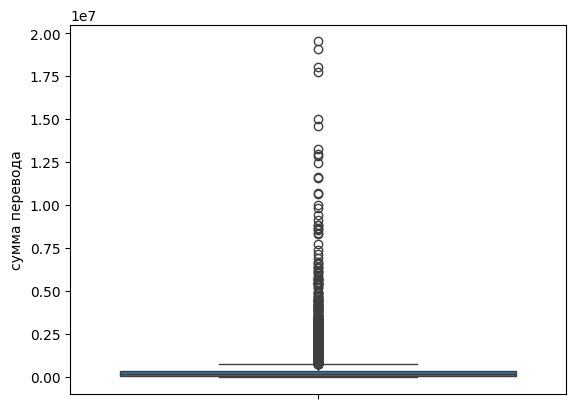

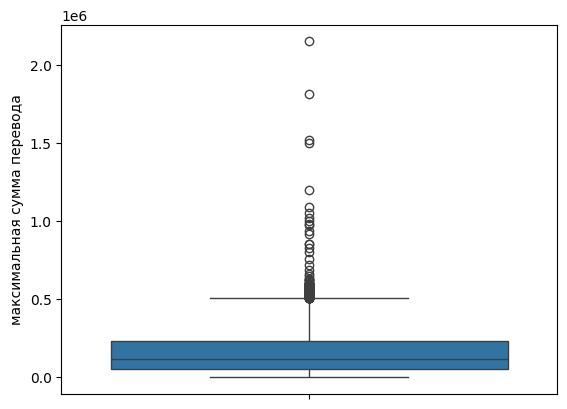

In [ ]:
# поиск и обработка аномальных записей
# непрерывные признаки
# обнаружение аномальных значений

# 1
# визуализация -- boxplot
for col in lst_vars_cont:
    sns.boxplot(df[col])
    plt.show()

In [ ]:
# фильтрация аномалий
filtered = (
    (df['количество переводов'].between(calc_boxplot(df['количество переводов'])[0],
                                        df['количество переводов'].quantile(0.99))) &
    (df['максимальная сумма перевода'].between(calc_boxplot(df['максимальная сумма перевода'])[0],
                                        df['максимальная сумма перевода'].quantile(0.99))) &
    (df['сумма перевода'].between(calc_boxplot(df['сумма перевода'])[0],
                                  df['сумма перевода'].quantile(0.99)))
    )

In [ ]:
# очищенные данные
df.loc[filtered];

# процент потерь
(1 - df.loc[filtered].shape[0] / df.shape[0])*100
#df.loc[~filtered].shape[0]

2.5337871860460437

In [ ]:
# очищенные данные
df_filtered = df.loc[filtered]


# аномальные наблюдения
df_anomals = df.loc[~filtered]
#df_filtered.to_csv('llll.csv')

In [ ]:
# пропуски
df.isna().sum()

,0
идентификатор,0
дата рождения,0
дисциплина клиентов,1
количество переводов,66
тип переводов,33
география переводов,33
география телефона,1868
сумма перевода,66
максимальная сумма перевода,66
канал клиента,31


In [ ]:
# Выводы по данному этапу:
# - удалены дублирующийся и производный столбцы;
# - скорректированы заголовки признаков;
# - исправлены некорректные значения признаков;
# - скорректирован тип признака `дата рождения`;
# - обнаружены и удалены аномальные значения призанков;
# - отдельно по категориальным и непрерывным признакам исследованы
# аномальные значения.
# По непрерывным признакам составлено выражение
# для фильтрации аномальных значений -- процент потерь составил -- 2.53
# от исходного набора --- что является допустимым; аномальные значения выделены
# в отдельный набор и могут в дальнейшем исследоваться дополнительно.
# По категориальным признакам уставнолены редкие значения -- возможно их следует
# объединить в одну категорию. Оставим это замечание на дальнейшее коррективы.

# В по итогу проведения этого этапа можно сделать вывод о подготовке данных для
# дальнейшего исследования.

## Генерирование новых признаков

In [ ]:
# - добавим возраст клиента
# возраст = текущая дата - дата рождения
#текущая дата
dt.date(2025, 12, 5)

# разность дат
def get_age(date_br):
    """
    """
    age = 0
    tzinfo=dt.timezone(dt.timedelta(0, 10800), 'MSK')
    #age = (dt.date(2025, 12, 5) - date_br.date())/np.timedelta(1, 'Y')
    x_year = dt.datetime.now(tz=tzinfo).date().year
    y_year = date_br.year
    x_month = dt.datetime.now(tz=tzinfo).date().month
    y_month = date_br.month
    x_day = dt.datetime.now(tz=tzinfo).date().day
    y_day = date_br.day

    #return (dt.date(2025, 12, 5) - date_br.date()) / np.timedelta64(1, 's')

    if x_month > y_month:
        return x_year - y_year
    elif x_month == y_month:
        if x_day > y_day:
            return x_year - y_year
        else:
            return x_year - y_year - 1

In [ ]:
df_filtered.loc[:, 'возраст клиента'] = df_filtered['дата рождения'].apply(get_age)

## Исследовательский анализ данных

In [ ]:
# в данном случае интерес представляет признак -- дисциплина клиента,
# иными словами нужно понять, чем отличаются ушедшие и оставшиеся клиенты

# рассмотрим случай непрерывных переменных
# оценим выборочные статистики в разрезе интересующего (целевого) признака

(
    df_filtered.groupby('дисциплина клиентов')[lst_vars_cont]
               .agg(['mean', 'median'])
)

количество переводов            сумма перевода            \
                                    mean median               mean    median   
дисциплина клиентов                                                            
BAD                         9.8899779736    6.0  208428.7797202643  137070.0   
GOOD                       14.3447589901    9.0  271694.3358056618  194731.0   
MIDDLE                     15.3155656796   10.0  264029.8060174639  183495.0   

                    максимальная сумма перевода                      age  \
                                           mean    median           mean   
дисциплина клиентов                                                        
BAD                           149296.4901134361  100000.0  52.2628854626   
GOOD                          168505.2333974752  125000.0  56.1538255547   
MIDDLE                        160649.5497934700  115000.0  53.7375854214   

                            
                    median  
дисциплина клиентов         
BAD                   51.0  
GOOD                  56.0  
MIDDLE                53.0

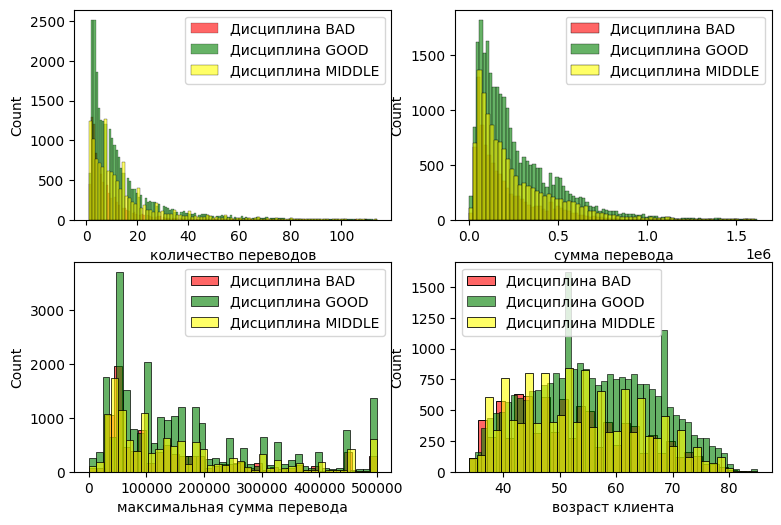

In [ ]:
# построим графики распределений для непрерывных признаков

# зададим цвета для значений целевого признака
dct_color = {'BAD': 'red',
             'MIDDLE': 'yellow',
             'GOOD': 'green'}

# добавим новый признак к списку непрерывных признаков
lst_vars_cont.extend(['возраст клиента'])

plt.subplots(2,2, figsize=(9,6))
for index, col in enumerate(lst_vars_cont, start=1):
    plt.subplot(2,2, index)
    for value in df_filtered['дисциплина клиентов'].unique():
        sns.histplot(x=df_filtered[df_filtered['дисциплина клиентов'] == value][col],
                     color=dct_color.get(value),
                     alpha=0.6,
                     label=f'Дисциплина {value}')
        plt.legend()

In [ ]:
# исследуем распределение значений категориальных признаков в разрезе целевой переменной

for col in lst_vars_cat:
    lst = ['дисциплина клиентов']
    lst.extend([col])
    df_left = (
        df_filtered.groupby(lst)
                .agg(count_clients = ('идентификатор', 'count'))
                .reset_index()
               )

    df_right = (
    df_filtered.groupby(col)
               .agg(count_clients = ('идентификатор', 'count'))
               .reset_index()
                )

    df_join = pd.merge(df_left, df_right,
                   how='inner',
                   on=col,
                   suffixes=['_part', '_full'])

    df_join['perc'] = (df_join['count_clients_part'] / df_join['count_clients_full']).round(4)*100
    df_ok = df_join.pivot_table(index='дисциплина клиентов',
                                columns=col,
                                values='perc').fillna(0)

    display(df_ok)
    print()

тип переводов,-1.0,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,...,44.0,45.0,53.0,54.0,55.0,58.0,59.0,61.0,67.0,69.0
дисциплина клиентов,,,,,,,,,,,,,,,,,,,,,
BAD,0.0,17.04,41.44,20.21,24.14,60.0,12.23,26.02,15.67,34.54,...,27.87,59.87,50.0,0.0,0.0,18.60,0.0,0.0,0.0,15.24
GOOD,100.0,54.79,33.00,52.35,55.17,20.0,55.84,47.63,67.16,39.18,...,39.34,18.47,50.0,100.0,100.0,51.16,50.0,50.0,100.0,65.82
MIDDLE,0.0,28.17,25.55,27.44,20.69,20.0,31.93,26.30,17.16,26.28,...,32.79,21.66,0.0,0.0,0.0,30.23,50.0,50.0,0.0,18.94


география переводов,0.0,1.0,2.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,...,73.0,74.0,75.0,76.0,77.0,78.0,86.0,89.0,498001.0,498002.0
дисциплина клиентов,,,,,,,,,,,,,,,,,,,,,
BAD,16.28,23.08,26.26,22.22,0.0,33.33,16.67,40.0,7.13,75.0,...,19.37,31.96,50.0,17.84,18.54,12.87,4.0,10.0,0.0,33.33
GOOD,40.70,46.15,39.01,55.56,100.0,25.00,16.67,40.0,70.66,25.0,...,53.42,42.37,50.0,53.05,54.01,59.25,68.0,60.0,0.0,33.33
MIDDLE,43.02,30.77,34.73,22.22,0.0,41.67,66.67,20.0,22.21,0.0,...,27.20,25.67,0.0,29.11,27.46,27.88,28.0,30.0,100.0,33.33


канал клиента,Офис,Партнер,Стойка
дисциплина клиентов,,,
BAD,14.90,22.76,21.90
GOOD,59.41,48.28,50.43
MIDDLE,25.68,28.96,27.67


оператор связи,Адыгейская сотовая связь,Архангельские Мобильные Сети,Астарта,Астрахань GSM,Байкалвестком,Белгородская Сотовая Связь,Беспровод. инф. технологи,Волгоград-GSM,Вотек Мобайл,Вымпел-Коммуникации,...,Сибирская Сотовая Связь,Смоленская Сотовая Связь,Сот.св.Башкортостана,Сотовая Связь Удмуртии,Средневолжская межрегиональная ассоциация радиотел,Телеком Евразия,Телесет Лтд.,Финансовая компания ИМПЕРАТИВ,Челябинская Сотовая Связь,Ярославль-GSM
дисциплина клиентов,,,,,,,,,,,,,,,,,,,,,
BAD,100.0,0.0,0.0,0.00,0.0,23.26,0.0,20.14,22.87,18.25,...,17.84,14.88,0.0,28.16,13.51,38.18,16.07,0.0,33.77,0.0
GOOD,0.0,0.0,100.0,85.71,50.0,37.21,0.0,53.96,49.56,54.44,...,58.38,66.53,50.0,47.57,51.35,40.91,37.50,100.0,40.15,60.0
MIDDLE,0.0,100.0,0.0,14.29,50.0,39.53,100.0,25.90,27.57,27.31,...,23.78,18.60,50.0,24.27,35.14,20.91,46.43,0.0,26.08,40.0


пол,Ж,М
дисциплина клиентов,,
BAD,17.88,19.69
GOOD,54.90,53.09
MIDDLE,27.22,27.22


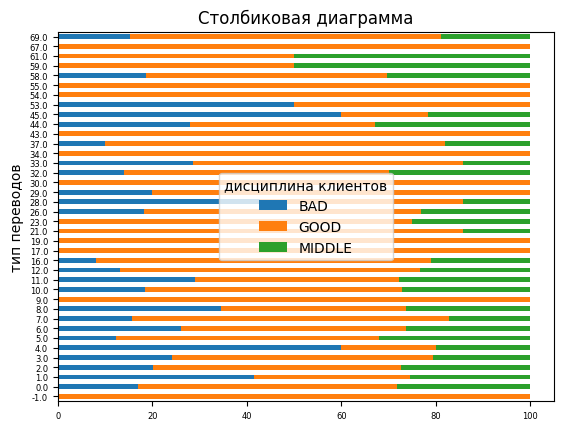

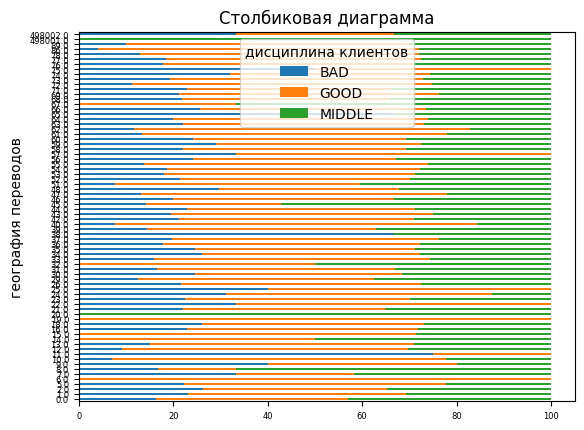

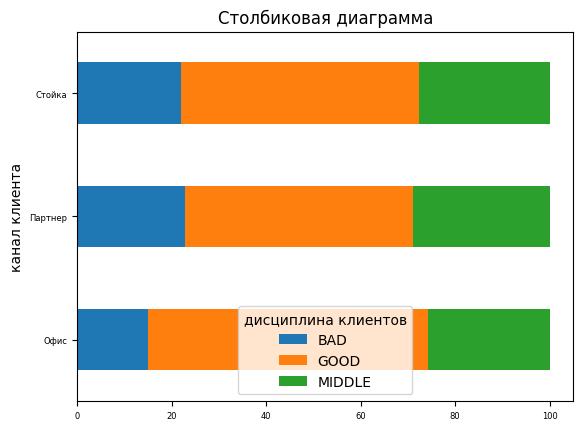

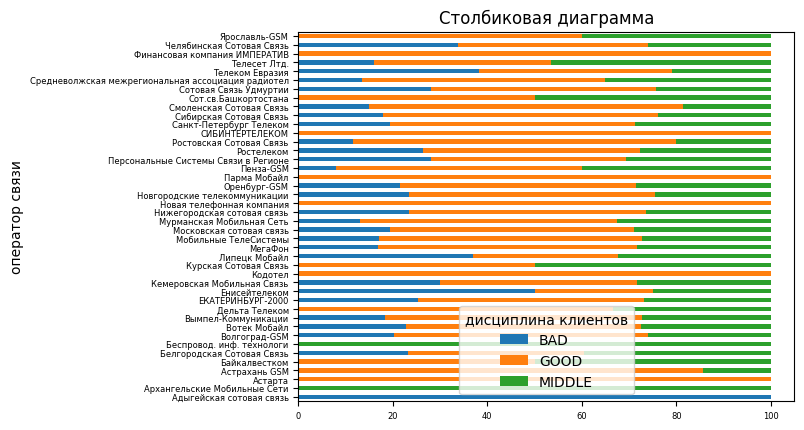

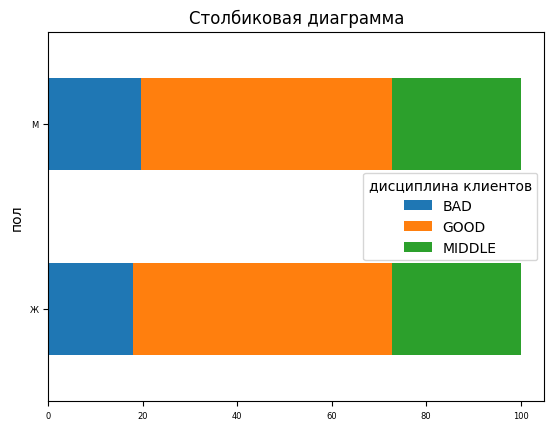

In [ ]:
# визуализация
for col in lst_vars_cat:
    lst = ['дисциплина клиентов']
    lst.extend([col])
    df_left = (
        df_filtered.groupby(lst)
                .agg(count_clients = ('идентификатор', 'count'))
                .reset_index()
               )

    df_right = (
    df_filtered.groupby(col)
               .agg(count_clients = ('идентификатор', 'count'))
               .reset_index()
                )

    df_join = pd.merge(df_left, df_right,
                   how='inner',
                   on=col,
                   suffixes=['_part', '_full'])

    df_join['perc'] = (df_join['count_clients_part'] / df_join['count_clients_full']).round(4)*100

    df_pivot = df_join.pivot_table(index='дисциплина клиентов',
                                columns=col,
                                values='perc').fillna(0)

    (df_pivot.T.reset_index()).plot(
        x = col,
        kind = 'barh',
        stacked = True,
        title = 'Столбиковая диаграмма',
        mark_right = True,
        fontsize=6)

In [ ]:
# Выводы по этапу:
# - анализ выборочных статистик и распределений значений непрерывных признаков
# позволяет предположить, что клиенты с дисциплиной "GOOD" совершают большее количество переводов и,
# как следствие, с большей общей суммой; можно предположить также, что более возрастные клиенты,
# граница 53 года, также будут иметь дисциплину "GOOD";
# - анализ распределения процентных значений категориальных признаков позволяет предположить,
# что более надежные клиенты приходят через канал "Офис".

In [ ]:
# Итоговые выводы по проекту:
# Сильный предиктор: Основными факторами, отличающими надежных клиентов, являются высокая транзакционная активность (больше переводов на крупные суммы) и более старший возраст.
# Качество трафика: Клиенты, привлеченные через «Офис», демонстрируют наилучшую платежную дисциплину. Каналы «Партнер» и «Стойка» дают больший процент проблемных заемщиков.
# Гендерный фактор: Пол клиента не влияет на его кредитную дисциплину — распределение мужчин и женщин по группам BAD, GOOD, MIDDLE практически идентично.
# Рекомендации для бизнеса
# Для кредитного конвейера: Учитывать возраст и транзакционную активность как дополнительные веса в скоринговых моделях.
# Для отдела маркетинга:
# Сегмент GOOD: Предлагать продукты с повышенным кредитным лимитом и премиальные карты.
# Сегмент BAD: Рассмотреть возможность предложения кредитных продуктов с более низкими лимитами и повышенным контролем.
# Для отдела привлечения: Пересмотреть эффективность каналов «Партнер» и «Стойка». Возможно, клиенты из этих каналов требуют более тщательной проверки на входе или для них нужны отдельные, более консервативные кредитные предложения.